In [2]:
import pandas as pd

df = pd.read_csv('supply_chain_data.csv')

print(df.shape)
print(df.columns.tolist())

(100, 24)
['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']


# Supply Chain Performance Analysis

## Project Objective

The objective of this project is to analyze supply chain performance and identify inefficiencies related to revenue, inventory, suppliers, manufacturing, and logistics.

## Main Business Question

Where are the biggest inefficiencies in the supply chain?

In [3]:
# Initial dataset overview

print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst rows:")
display(df.head())

Dataset shape:
(100, 24)

Column names:
['Product type', 'SKU', 'Price', 'Availability', 'Number of products sold', 'Revenue generated', 'Customer demographics', 'Stock levels', 'Lead times', 'Order quantities', 'Shipping times', 'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'Inspection results', 'Defect rates', 'Transportation modes', 'Routes', 'Costs']

First rows:


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [4]:
# Missing values

df.isnull().sum().sort_values(ascending=False)

,0
Product type,0
SKU,0
Price,0
Availability,0
Number of products sold,0
Revenue generated,0
Customer demographics,0
Stock levels,0
Lead times,0
Order quantities,0


# 1. Understanding the Dataset

Before performing the analysis, the dataset structure and data quality were reviewed.

The dataset contains information related to products, inventory, suppliers, manufacturing operations, logistics, and revenue generation.

A missing value check confirmed that all variables are complete and suitable for analysis.

# 2. Revenue Analysis

## Business Question

Which product categories generate the most revenue?

In [5]:
revenue_by_product = (
    df.groupby('Product type')['Revenue generated']
    .sum()
    .sort_values(ascending=False)
)

revenue_by_product

,Revenue generated
Product type,
skincare,241628.162133
haircare,174455.390605
cosmetics,161521.265999


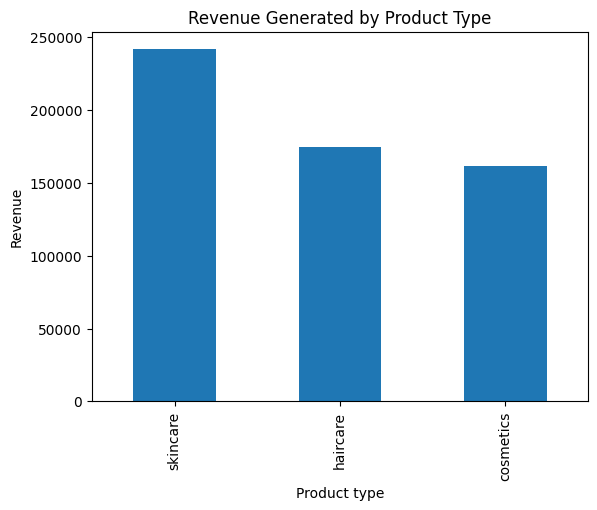

In [6]:
import matplotlib.pyplot as plt

revenue_by_product.plot(
    kind='bar'
)

plt.title('Revenue Generated by Product Type')
plt.ylabel('Revenue')
plt.show()

In [7]:
revenue_by_product

,Revenue generated
Product type,
skincare,241628.162133
haircare,174455.390605
cosmetics,161521.265999


### Findings

Skincare generated the highest revenue (241.6K), followed by haircare (174.5K) and cosmetics (161.5K).

Among the three product categories, skincare appears to be the main revenue driver.

### Business Interpretation

Because skincare products generate the most revenue, maintaining inventory availability for this category should be a priority.

Any disruption affecting skincare products would likely have a greater impact on overall business performance than disruptions affecting the other categories.

# 3. Inventory Analysis

## Business Question

Which product categories maintain the highest inventory levels?

In [8]:
stock_by_product = (
    df.groupby('Product type')['Stock levels']
    .mean()
    .sort_values(ascending=False)
)

stock_by_product

,Stock levels
Product type,
cosmetics,58.653846
haircare,48.352941
skincare,40.200000


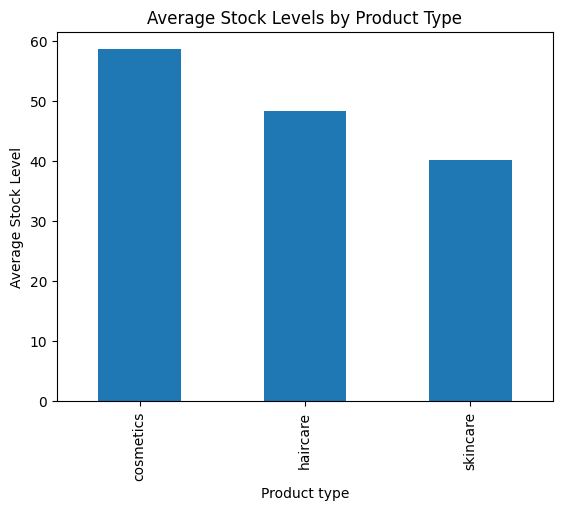

In [9]:
import matplotlib.pyplot as plt

stock_by_product.plot(kind='bar')

plt.title('Average Stock Levels by Product Type')
plt.ylabel('Average Stock Level')
plt.show()

### Findings

Skincare products generated the most revenue, even though they had the lowest average inventory levels.

On the other hand, cosmetics maintained the highest inventory levels while generating the lowest revenue of the three product categories.

### Business Interpretation

The current inventory allocation may not reflect product performance.

Skincare products appear to be selling efficiently despite lower stock levels, while cosmetics are holding more inventory without generating comparable revenue.

This could indicate an opportunity to review inventory planning and better align stock levels with demand.

# 4. Supplier Performance Analysis

## Business Question

Which suppliers have the highest defect rates?

In [10]:
supplier_defects = (
    df.groupby('Supplier name')['Defect rates']
    .mean()
    .sort_values(ascending=False)
)

supplier_defects

,Defect rates
Supplier name,
Supplier 5,2.665408
Supplier 3,2.465786
Supplier 2,2.362750
Supplier 4,2.337397
Supplier 1,1.803630


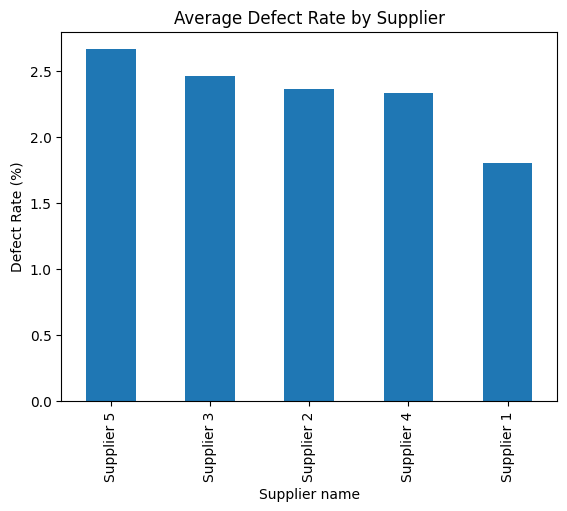

In [11]:
supplier_defects.plot(kind='bar')

plt.title('Average Defect Rate by Supplier')
plt.ylabel('Defect Rate (%)')
plt.show()

### Findings

Supplier 5 recorded the highest average defect rate (2.67%), while Supplier 1 showed the lowest rate (1.80%).

Overall, defect rates were relatively similar across suppliers.

### Business Interpretation

No supplier appears to be a major quality concern at this stage.

However, Supplier 5 may require additional monitoring to ensure defect rates do not increase over time.

# 5. Lead Time Analysis

## Business Question

Which suppliers have the longest lead times?

In [12]:
supplier_leadtime = (
    df.groupby('Supplier name')['Lead time']
    .mean()
    .sort_values(ascending=False)
)

supplier_leadtime

,Lead time
Supplier name,
Supplier 3,20.133333
Supplier 2,18.545455
Supplier 5,18.055556
Supplier 4,15.222222
Supplier 1,14.777778


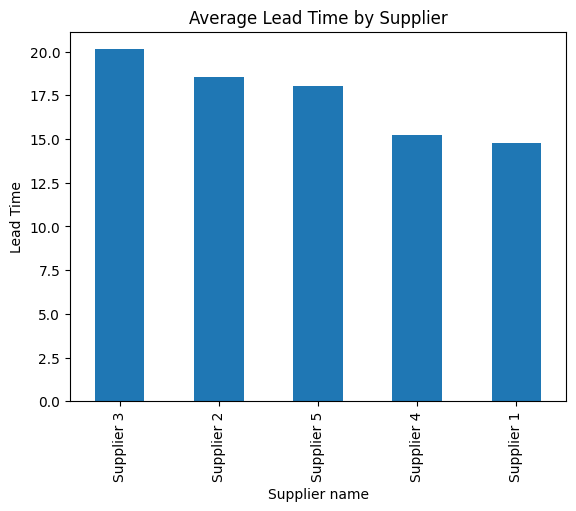

In [13]:
supplier_leadtime.plot(kind='bar')

plt.title('Average Lead Time by Supplier')
plt.ylabel('Lead Time')
plt.show()

### Findings

Supplier 3 reported the longest average lead time (20.1 days), while Supplier 1 had the shortest lead time (14.8 days).

The gap between the fastest and slowest suppliers exceeds five days, indicating noticeable differences in supplier responsiveness.

### Business Interpretation

Longer lead times can make inventory planning more challenging and increase the risk of stock shortages.

Supplier 3 may require closer monitoring, as consistently longer lead times could affect product availability and overall supply chain performance.


In [14]:
supplier_performance = (
    df.groupby('Supplier name')
    .agg({
        'Lead time':'mean',
        'Defect rates':'mean'
    })
    .sort_values('Lead time', ascending=False)
)

supplier_performance

,Lead time,Defect rates
Supplier name,,
Supplier 3,20.133333,2.465786
Supplier 2,18.545455,2.362750
Supplier 5,18.055556,2.665408
Supplier 4,15.222222,2.337397
Supplier 1,14.777778,1.803630


### Findings

Supplier 3 had the longest average lead time (20.1 days), while Supplier 5 had the highest average defect rate (2.67%).

Supplier 1 performed best across both metrics, with the shortest lead time and the lowest defect rate.

### Business Interpretation

There is no single supplier that performs worst across both lead time and defect rate.

However, Supplier 3 should be monitored for delivery speed, while Supplier 5 may need closer quality control. Supplier 1 could be used as a benchmark for stronger supplier performance.

# 6. Manufacturing Analysis

## Business Question

Which product categories have the highest defect rates?

In [15]:
defects_by_product = (
    df.groupby('Product type')['Defect rates']
    .mean()
    .sort_values(ascending=False)
)

defects_by_product

,Defect rates
Product type,
haircare,2.483150
skincare,2.334681
cosmetics,1.919287


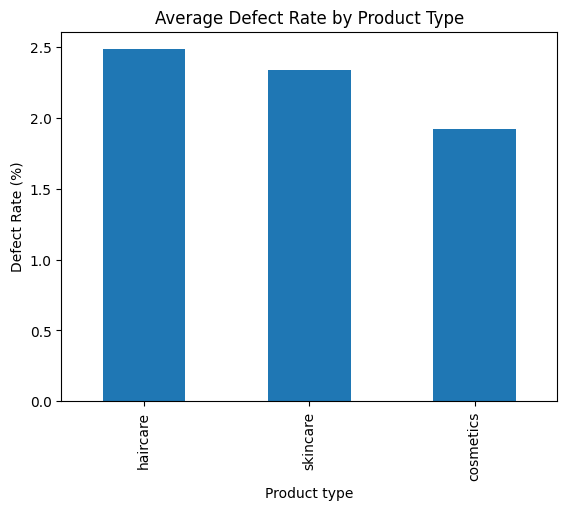

In [16]:
defects_by_product.plot(kind='bar')

plt.title('Average Defect Rate by Product Type')
plt.ylabel('Defect Rate (%)')
plt.show()

### Findings

Haircare products recorded the highest average defect rate (2.48%), followed by skincare products (2.33%).

Cosmetics showed the lowest defect rate among the three product categories.

### Business Interpretation

Although defect rates are relatively close across product categories, haircare products appear to face more quality-related issues than the rest of the portfolio.

Reducing defects in this category could help improve operational efficiency and reduce unnecessary manufacturing costs.

# 7. Logistics Analysis

## Business Question

Which transportation modes are associated with the highest shipping costs?

In [17]:
shipping_by_mode = (
    df.groupby('Transportation modes')['Shipping costs']
    .mean()
    .sort_values(ascending=False)
)

shipping_by_mode

,Shipping costs
Transportation modes,
Air,6.017839
Road,5.542115
Rail,5.469098
Sea,4.970294


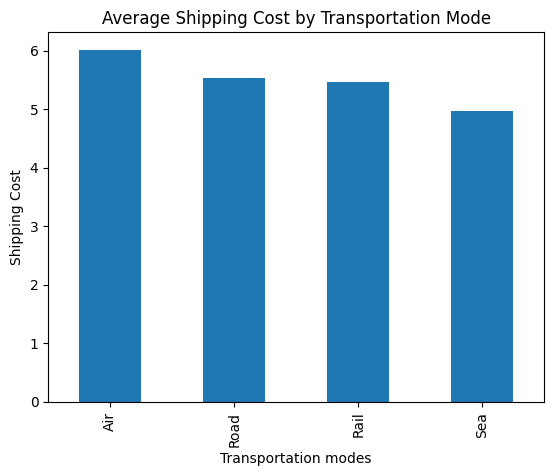

In [18]:
shipping_by_mode.plot(kind='bar')

plt.title('Average Shipping Cost by Transportation Mode')
plt.ylabel('Shipping Cost')
plt.show()

### Findings

Air transportation had the highest average shipping cost ($6.02), while sea transportation showed the lowest average cost ($4.97).

Road and rail transportation reported similar average shipping costs.

### Business Interpretation

The choice of transportation mode has a direct impact on logistics costs.

Air transportation may be appropriate for time-sensitive shipments, but sea transportation appears to be the most cost-efficient option when delivery speed is less critical.

# 8. Final Conclusions

### Key Takeaways

- Skincare products stood out as the main revenue driver in the dataset.

- One of the most interesting findings was that skincare generated the highest revenue while maintaining the lowest average stock levels.

- Supplier performance was relatively stable, although Supplier 3 had longer lead times and Supplier 5 showed slightly higher defect rates than the rest of the supplier network.

- Haircare products experienced the highest defect rates, suggesting an opportunity to improve quality control processes.

- From a logistics perspective, air transportation was the most expensive option, while sea transportation appeared to be the most cost-efficient.